In [ ]:
from pathlib import Path
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = Path("home-credit-default-risk")

# Load Data

In [2]:
def load_csv(filename):
    df = pd.read_csv(DATA_DIR / filename, low_memory=False)  # read from project data dir
    print(f"{filename}: {df.shape}")                         # traceability: show rows/cols
    return df                                                # return dataframe unchanged

In [3]:
def agg_numeric(df, group_var, df_name, agg_funcs=("mean", "max", "min", "sum")):
    df_name = str(df_name).upper()

    g = df.groupby(group_var)  # group to customer-level )
    counts = g.size().rename(f"{df_name}_ROW_COUNT").reset_index()  # row-count feature

    # numeric columns excluding group key and other SK_ID* columns
    num_cols = [
        c for c in df.select_dtypes(include=np.number).columns
        if c != group_var
    ]
    if len(num_cols) == 0:
        return counts  # only row-count available

    agg = g[num_cols].agg(agg_funcs)  # aggregate numeric signals per group
    agg.columns = [f"{df_name}_{col}_{stat}".upper() for col, stat in agg.columns]  # flatten MultiIndex
    agg = agg.reset_index()

    return agg.merge(counts, on=group_var, how="left") 


In [4]:
def count_categorical(df, group_var, df_name):
    df_name = str(df_name).upper()

    # categorical-like columns excluding key
    cat_cols = [
        c for c in df.select_dtypes(include=["object", "category", "bool"]).columns
        if c != group_var
    ]
    if len(cat_cols) == 0:
        return df[[group_var]].drop_duplicates().reset_index(drop=True)  # keep key only

    # one-hot + NA bucket; uint8 saves memory for wide dummy matrices
    dummies = pd.get_dummies(df[cat_cols], dummy_na=True).astype(np.uint8)
    dummies[group_var] = df[group_var].values  # attach group key for aggregation

    out = dummies.groupby(group_var).agg(["sum", "mean"])  # COUNT and COUNT_NORM
    out.columns = [
        f"{df_name}_{col}_{'COUNT' if stat == 'sum' else 'COUNT_NORM'}".upper()
        for col, stat in out.columns
    ]
    return out.reset_index()


In [5]:
def agg_all(df, group_var, df_name):
    num = agg_numeric(df, group_var, df_name)          # numeric aggregates + row count
    cat = count_categorical(df, group_var, df_name)    # categorical COUNT / COUNT_NORM
    return num.merge(cat, on=group_var, how="left")    # unify per-table features


application_train.csv: (307511, 122)
application_test.csv: (48744, 121)
app (train+test): (356255, 123)


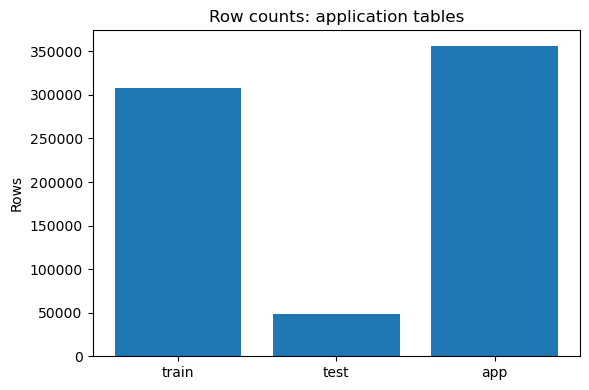

In [6]:
train = load_csv("application_train.csv")
test  = load_csv("application_test.csv")

train["_is_train"] = 1                 # flag original train rows
test["_is_train"]  = 0                 # flag original test rows
test["TARGET"]     = np.nan            # align schema for concat

app = pd.concat([train, test], ignore_index=True, sort=False)  # unified application table
print("app (train+test):", app.shape)

# simple diagnostic: row counts
plt.figure(figsize=(6, 4))
plt.bar(["train", "test", "app"], [train.shape[0], test.shape[0], app.shape[0]])
plt.title("Row counts: application tables")
plt.ylabel("Rows")
plt.tight_layout()
plt.show()


In [7]:
bureau = load_csv("bureau.csv")
bb = load_csv("bureau_balance.csv")

bureau_cols_before = bureau.shape[1]  # raw bureau column count

# 1) bureau_balance -> SK_ID_BUREAU aggregation, then merge into bureau
bb_agg = agg_all(bb, group_var="SK_ID_BUREAU", df_name="bureau_balance")  # one row per SK_ID_BUREAU
bureau = bureau.merge(bb_agg, on="SK_ID_BUREAU", how="left")              # enrich bureau with bb signals
bureau_cols_after_bb = bureau.shape[1]                                   # expanded column count


del bb, bb_agg
gc.collect()


bureau.csv: (1716428, 17)
bureau_balance.csv: (27299925, 3)


3026

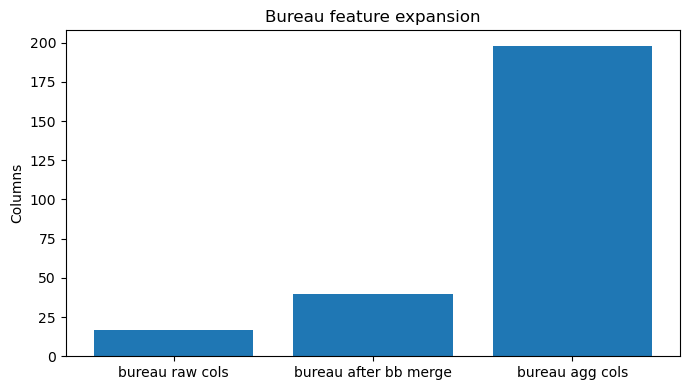

3215

In [8]:
# 2) bureau (enriched) -> SK_ID_CURR aggregation (customer-level)
bureau_agg_all = agg_all(bureau, group_var="SK_ID_CURR", df_name="bureau")  # one row per SK_ID_CURR

# diagnostic: how many columns were added / kept
plt.figure(figsize=(7, 4))
plt.bar(
    ["bureau raw cols", "bureau after bb merge", "bureau agg cols"],
    [bureau_cols_before, bureau_cols_after_bb, bureau_agg_all.shape[1]]
)
plt.title("Bureau feature expansion")
plt.ylabel("Columns")
plt.tight_layout()
plt.show()

gc.collect()

previous_application.csv: (1670214, 37)
POS_CASH_balance.csv: (10001358, 8)
credit_card_balance.csv: (3840312, 23)
installments_payments.csv: (13605401, 8)


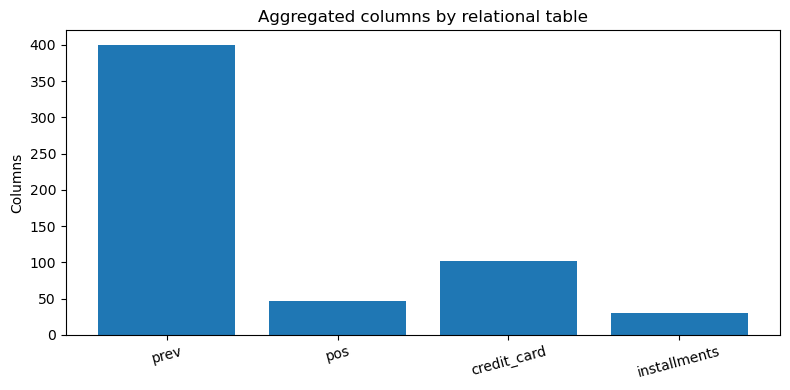

In [9]:
# Aggregate all remaining relational tables to one row per SK_ID_CURR.

prev = load_csv("previous_application.csv")
prev_agg = agg_all(prev, group_var="SK_ID_CURR", df_name="prev_app")
prev_cols = prev_agg.shape[1]
del prev
gc.collect()

pos = load_csv("POS_CASH_balance.csv")
pos_agg = agg_all(pos, group_var="SK_ID_CURR", df_name="pos_cash")
pos_cols = pos_agg.shape[1]
del pos
gc.collect()

cc = load_csv("credit_card_balance.csv")
cc_agg = agg_all(cc, group_var="SK_ID_CURR", df_name="credit_card")
cc_cols = cc_agg.shape[1]
del cc
gc.collect()

ins = load_csv("installments_payments.csv")
ins_agg = agg_all(ins, group_var="SK_ID_CURR", df_name="installments")
ins_cols = ins_agg.shape[1]
del ins
gc.collect()

plt.figure(figsize=(8, 4))
plt.bar(["prev", "pos", "credit_card", "installments"], [prev_cols, pos_cols, cc_cols, ins_cols])
plt.title("Aggregated columns by relational table")
plt.ylabel("Columns")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [10]:
merge_pairs = [
    ("bureau", bureau_agg_all),
    ("prev_app", prev_agg),
    ("pos_cash", pos_agg),
    ("credit_card", cc_agg),
    ("installments", ins_agg),
]

merge_stats = []
for name, feat_df in merge_pairs:
    cols_before = app.shape[1]
    app = app.merge(feat_df, on="SK_ID_CURR", how="left")
    cols_after = app.shape[1]
    merge_stats.append({
        "table": name,
        "cols_before": cols_before,
        "cols_after": cols_after,
        "cols_added": cols_after - cols_before,
    })

print("joined app:", app.shape)

train_joined = app[app["_is_train"] == 1].copy()
test_joined  = app[app["_is_train"] == 0].copy()

print("train_joined:", train_joined.shape)
print("test_joined:", test_joined.shape)

train_joined.head()

joined app: (356255, 894)
train_joined: (307511, 894)
test_joined: (48744, 894)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,INSTALLMENTS_DAYS_ENTRY_PAYMENT_SUM,INSTALLMENTS_AMT_INSTALMENT_MEAN,INSTALLMENTS_AMT_INSTALMENT_MAX,INSTALLMENTS_AMT_INSTALMENT_MIN,INSTALLMENTS_AMT_INSTALMENT_SUM,INSTALLMENTS_AMT_PAYMENT_MEAN,INSTALLMENTS_AMT_PAYMENT_MAX,INSTALLMENTS_AMT_PAYMENT_MIN,INSTALLMENTS_AMT_PAYMENT_SUM,INSTALLMENTS_ROW_COUNT
0,100002,1.0,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,-5993.0,11559.247105,53093.745,9251.775,219625.695,11559.247105,53093.745,9251.775,219625.695,19.0
1,100003,0.0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,-34633.0,64754.586000,560835.360,6662.970,1618864.650,64754.586000,560835.360,6662.970,1618864.650,25.0
2,100004,0.0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,-2285.0,7096.155000,10573.965,5357.250,21288.465,7096.155000,10573.965,5357.250,21288.465,3.0
3,100006,0.0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,-4346.0,62947.088438,691786.890,2482.920,1007153.415,62947.088438,691786.890,2482.920,1007153.415,16.0
4,100007,0.0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,-68128.0,12666.444545,22678.785,1821.780,835985.340,12214.060227,22678.785,0.180,806127.975,66.0


# EDA

In [11]:
# 1. Data Profiling: Consolidate missing values and uniqueness checks
# Using a single pass for missing values to save memory/time
missing_series = train_joined.isna().mean()
nunique_series = train_joined.nunique(dropna=False)

baseline_profile = pd.DataFrame({
    'column': train_joined.columns,
    'dtype': train_joined.dtypes.astype(str).values,
    'missing_rate': missing_series.values,
    'nunique': nunique_series.values,
}).sort_values(['missing_rate', 'nunique'], ascending=[False, False]).reset_index(drop=True)

# 2. Sentinel Value Audit: Specifically for DAYS_EMPLOYED = 365243
# In Home Credit data, 365243 usually means "Retired" or "Unemployed"
sentinel_cols = [c for c in ['DAYS_EMPLOYED', 'DAYS_BIRTH', 'DAYS_LAST_PHONE_CHANGE'] if c in train_joined.columns]
sentinel_summary = []

for c in sentinel_cols:
    is_numeric = pd.api.types.is_numeric_dtype(train_joined[c])
    sentinel_summary.append({
        'column': c,
        'count_365243': int((train_joined[c] == 365243).sum()) if is_numeric else 0,
        'min': float(train_joined[c].min()) if is_numeric else np.nan,
        'max': float(train_joined[c].max()) if is_numeric else np.nan,
    })

# 3. Logical Integrity & Domain Rule Checks
# These rules detect "impossible" data scenarios that could mislead the model
rules = []

# Financial Non-negativity Checks
for col in ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']:
    if col in train_joined.columns:
        rules.append({
            'rule': f'{col} <= 0', 
            'count': int((train_joined[col] <= 0).sum())
        })

# Family Composition Consistency
if {'CNT_CHILDREN', 'CNT_FAM_MEMBERS'}.issubset(train_joined.columns):
    rules.append({
        'rule': 'Children > Family Members', 
        'count': int((train_joined['CNT_CHILDREN'] > train_joined['CNT_FAM_MEMBERS']).sum())
    })

# Loan Structure Logic (Annuity should generally be less than Total Credit)
if {'AMT_ANNUITY', 'AMT_CREDIT'}.issubset(train_joined.columns):
    rules.append({
        'rule': 'Annuity > Credit (Impossible Term)', 
        'count': int((train_joined['AMT_ANNUITY'] > train_joined['AMT_CREDIT']).sum())
    })

# Demographic Validity (Age & Employment)
if 'DAYS_BIRTH' in train_joined.columns:
    age_years = train_joined['DAYS_BIRTH'].abs() / 365.25
    rules.append({'rule': 'Age < 18 years', 'count': int((age_years < 18).sum())})
    rules.append({'rule': 'Age > 100 years', 'count': int((age_years > 100).sum())})

if {'DAYS_EMPLOYED', 'DAYS_BIRTH'}.issubset(train_joined.columns):
    # Filter out the 365243 sentinel before comparing employment to age
    employed_days = train_joined['DAYS_EMPLOYED'].replace(365243, np.nan).abs()
    age_days = train_joined['DAYS_BIRTH'].abs()
    rules.append({
        'rule': 'Employment tenure > Age', 
        'count': int((employed_days > age_days).fillna(False).sum())
    })

# 4. Final Reporting
rule_checks = pd.DataFrame(rules)
if not rule_checks.empty:
    rule_checks['share'] = rule_checks['count'] / len(train_joined)

print("--- TOP 20 COLUMNS BY MISSING RATE ---")
display(baseline_profile.head(20))

print("\n--- SENTINEL VALUE (365243) SUMMARY ---")
display(pd.DataFrame(sentinel_summary))

print("\n--- DATA RULE VIOLATIONS ---")
display(rule_checks.sort_values('count', ascending=False) if not rule_checks.empty else "No violations found.")



--- TOP 20 COLUMNS BY MISSING RATE ---


,column,dtype,missing_rate,nunique
0,PREV_APP_RATE_INTEREST_PRIMARY_MEAN,float64,0.985012,185
1,PREV_APP_RATE_INTEREST_PRIMARY_MAX,float64,0.985012,135
2,PREV_APP_RATE_INTEREST_PRIMARY_MIN,float64,0.985012,134
3,PREV_APP_RATE_INTEREST_PRIVILEGED_MEAN,float64,0.985012,46
4,PREV_APP_RATE_INTEREST_PRIVILEGED_MAX,float64,0.985012,24
5,PREV_APP_RATE_INTEREST_PRIVILEGED_MIN,float64,0.985012,24
6,CREDIT_CARD_AMT_PAYMENT_CURRENT_MEAN,float64,0.801438,56765
7,CREDIT_CARD_AMT_PAYMENT_CURRENT_MAX,float64,0.801438,25754
8,CREDIT_CARD_AMT_PAYMENT_CURRENT_MIN,float64,0.801438,9924
9,CREDIT_CARD_AMT_DRAWINGS_POS_CURRENT_MEAN,float64,0.801178,33413



--- SENTINEL VALUE (365243) SUMMARY ---


,column,count_365243,min,max
0,DAYS_EMPLOYED,55374,-17912.0,365243.0
1,DAYS_BIRTH,0,-25229.0,-7489.0
2,DAYS_LAST_PHONE_CHANGE,0,-4292.0,0.0



--- DATA RULE VIOLATIONS ---


,rule,count,share
0,AMT_INCOME_TOTAL <= 0,0,0.0
1,AMT_CREDIT <= 0,0,0.0
2,AMT_ANNUITY <= 0,0,0.0
3,AMT_GOODS_PRICE <= 0,0,0.0
4,Children > Family Members,0,0.0
5,Annuity > Credit (Impossible Term),0,0.0
6,Age < 18 years,0,0.0
7,Age > 100 years,0,0.0
8,Employment tenure > Age,0,0.0


In [12]:
# 1. Full Row Duplication Report
# Checking if identical rows exist across the entire record
tables_to_check = [
    ('train', train), ('test', test), ('app', app), 
    ('bureau', bureau), ('bureau_agg_all', bureau_agg_all),
    ('prev_agg', prev_agg), ('pos_agg', pos_agg), 
    ('cc_agg', cc_agg), ('ins_agg', ins_agg)
]

dup_rows_data = []
for name, df in tables_to_check:
    dup_rows_data.append({
        'table': name, 
        'duplicate_rows': int(df.duplicated().sum()), 
        'row_count': len(df)
    })

duplicate_rows_report = pd.DataFrame(dup_rows_data)

# 2. Primary Key Integrity Report
# This is CRITICAL: If 'SK_ID_CURR' has duplicates in an aggregated table, 
# joining it to 'train' will create a Cartesian product and distort the data.
key_mapping = [
    ('train', train, 'SK_ID_CURR'),
    ('test', test, 'SK_ID_CURR'),
    ('app', app, 'SK_ID_CURR'),
    ('bureau', bureau, 'SK_ID_BUREAU'),
    ('bureau_agg_all', bureau_agg_all, 'SK_ID_CURR'),
    ('prev_agg', prev_agg, 'SK_ID_CURR'),
    ('pos_agg', pos_agg, 'SK_ID_CURR'),
    ('cc_agg', cc_agg, 'SK_ID_CURR'),
    ('ins_agg', ins_agg, 'SK_ID_CURR'),
]

key_dup_report = []
for name, df, key in key_mapping:
    if key in df.columns:
        key_dup_report.append({
            'table': name,
            'primary_key': key,
            'duplicate_keys': int(df.duplicated(subset=[key]).sum()),
            'unique_keys': int(df[key].nunique(dropna=False)),
            'key_nulls': int(df[key].isna().sum())
        })

# 3. Memory Management
# Remove the raw bureau table after verifying the aggregated version
print("--- Row-Level Duplicate Report ---")
display(duplicate_rows_report)

print("\n--- Key-Level Integrity Report (Check for Duplicate SK_IDs) ---")
display(pd.DataFrame(key_dup_report))

# Clean up memory
if 'bureau' in locals():
    del bureau
gc.collect()

--- Row-Level Duplicate Report ---


,table,duplicate_rows,row_count
0,train,0,307511
1,test,0,48744
2,app,0,356255
3,bureau,0,1716428
4,bureau_agg_all,0,305811
5,prev_agg,0,338857
6,pos_agg,0,337252
7,cc_agg,0,103558
8,ins_agg,0,339587



--- Key-Level Integrity Report (Check for Duplicate SK_IDs) ---


,table,primary_key,duplicate_keys,unique_keys,key_nulls
0,train,SK_ID_CURR,0,307511,0
1,test,SK_ID_CURR,0,48744,0
2,app,SK_ID_CURR,0,356255,0
3,bureau,SK_ID_BUREAU,0,1716428,0
4,bureau_agg_all,SK_ID_CURR,0,305811,0
5,prev_agg,SK_ID_CURR,0,338857,0
6,pos_agg,SK_ID_CURR,0,337252,0
7,cc_agg,SK_ID_CURR,0,103558,0
8,ins_agg,SK_ID_CURR,0,339587,0


0

### Label / Type / Unit Inconsistency Audit

Check categorical label normalization opportunities and numeric type/range consistency before preprocessing.

In [13]:
# 1. Categorical Normalization Audit
# Scan all text/categorical columns to see if cleaning (strip, uppercase, remove extra spaces)
# reduces the number of unique categories, which prevents duplicate One-Hot encoded columns.
cat_cols_raw = train_joined.select_dtypes(include=['object', 'category']).columns.tolist()
label_inconsistency_rows = []

for c in cat_cols_raw:
    # Drop NaNs before casting to string to avoid turning NaN into the string "NAN"
    s = train_joined[c].dropna().astype(str)
    if len(s) == 0:
        continue
    
    # Standardize string formatting: strip edges, replace multi-spaces with single space, uppercase
    normalized = s.str.strip().str.replace(r"\s+", " ", regex=True).str.upper()
    
    raw_unique = int(s.nunique())
    norm_unique = int(normalized.nunique())
    
    # Record columns where standardization successfully merged duplicate categories
    if norm_unique < raw_unique:
        label_inconsistency_rows.append({
            'column': c,
            'raw_unique': raw_unique,
            'normalized_unique': norm_unique,
            'reduction': raw_unique - norm_unique,
        })

label_inconsistency_report = pd.DataFrame(label_inconsistency_rows)
if not label_inconsistency_report.empty:
    label_inconsistency_report = label_inconsistency_report.sort_values('reduction', ascending=False)

# 2. Apply Categorical Normalization
# Apply the exact same string cleaning rules to all relevant dataframes before encoding.
# Using 'test_joined' (and 'app' if still needed) ensures consistent categories across train/test sets.
for df_ in [app, train_joined, test_joined]:
    # Only process columns that actually exist in the current dataframe
    valid_cols = [c for c in cat_cols_raw if c in df_.columns]
    for c in valid_cols:
        s = df_[c]
        mask = s.notna() # Only apply string operations to non-null values
        if mask.any():
            df_.loc[mask, c] = (
                s.loc[mask]
                .astype(str)
                .str.strip()
                .str.replace(r"\s+", " ", regex=True)
                .str.upper()
            )

# 3. Numeric Consistency Snapshot
# OPTIMIZATION: Extract numeric columns ONCE to save memory and computation time.
numeric_df = train_joined.select_dtypes(include=[np.number])

num_consistency = pd.DataFrame({
    'column': numeric_df.columns,
    'dtype': numeric_df.dtypes.astype(str).values,
    'min': numeric_df.min().values,
    'max': numeric_df.max().values,
    'missing_rate': numeric_df.isna().mean().values,
}).sort_values('missing_rate', ascending=False)

# 4. Final Reporting
print("--- Categorical Label Inconsistencies Fixed (Top Reductions) ---")
if label_inconsistency_report.empty:
    print("No categorical label inconsistencies found. Labels are clean.")
else:
    display(label_inconsistency_report.head(20))

print("\n--- Numeric Consistency Snapshot (Top Missing Rates) ---")
if num_consistency.empty:
    print("No numeric consistency report generated.")
else:
    display(num_consistency.head(20))

--- Categorical Label Inconsistencies Fixed (Top Reductions) ---
No categorical label inconsistencies found. Labels are clean.

--- Numeric Consistency Snapshot (Top Missing Rates) ---


,column,dtype,min,max,missing_rate
345,PREV_APP_RATE_INTEREST_PRIVILEGED_MAX,float64,0.373150,1.000000e+00,0.985012
346,PREV_APP_RATE_INTEREST_PRIVILEGED_MIN,float64,0.373150,1.000000e+00,0.985012
340,PREV_APP_RATE_INTEREST_PRIMARY_MEAN,float64,0.034781,1.000000e+00,0.985012
341,PREV_APP_RATE_INTEREST_PRIMARY_MAX,float64,0.034781,1.000000e+00,0.985012
342,PREV_APP_RATE_INTEREST_PRIMARY_MIN,float64,0.034781,1.000000e+00,0.985012
344,PREV_APP_RATE_INTEREST_PRIVILEGED_MEAN,float64,0.373150,1.000000e+00,0.985012
784,CREDIT_CARD_AMT_PAYMENT_CURRENT_MEAN,float64,0.000000,1.125000e+06,0.801438
786,CREDIT_CARD_AMT_PAYMENT_CURRENT_MIN,float64,0.000000,1.125000e+06,0.801438
785,CREDIT_CARD_AMT_PAYMENT_CURRENT_MAX,float64,0.000000,4.289207e+06,0.801438
766,CREDIT_CARD_AMT_DRAWINGS_ATM_CURRENT_MIN,float64,-6827.310000,9.045000e+05,0.801178


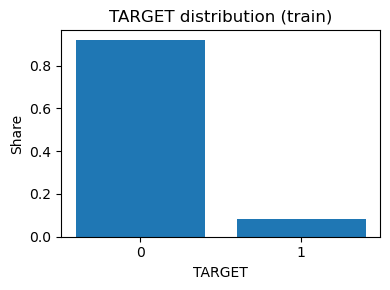

In [14]:
# EDA 1: TARGET distribution (train only)
y = train_joined["TARGET"].value_counts(normalize=True).sort_index()
plt.figure(figsize=(4,3))
plt.bar(y.index.astype(int).astype(str), y.values)
plt.xlabel("TARGET")
plt.ylabel("Share")
plt.title("TARGET distribution (train)")
plt.tight_layout()
plt.show()


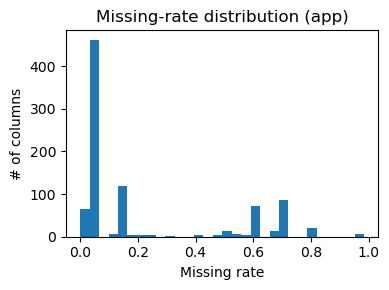

In [15]:
# EDA 2: Missing-rate distribution across ALL columns (app = train+test)
miss_rate = app.isna().mean()
plt.figure(figsize=(4,3))
plt.hist(miss_rate.values, bins=30)
plt.xlabel("Missing rate")
plt.ylabel("# of columns")
plt.title("Missing-rate distribution (app)")
plt.tight_layout()
plt.show()


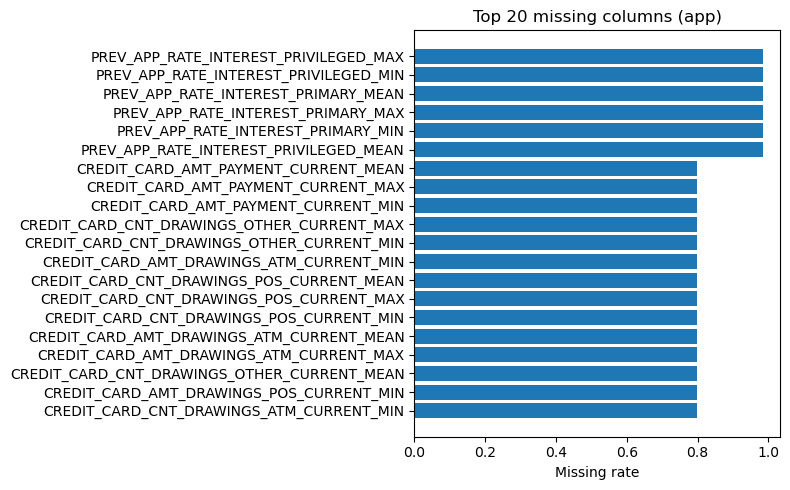

In [16]:
# EDA 3: Top missing columns (app)
top_miss = app.isna().mean().sort_values(ascending=False).head(20)
plt.figure(figsize=(8,5))
plt.barh(top_miss.index[::-1], top_miss.values[::-1])
plt.xlabel("Missing rate")
plt.title("Top 20 missing columns (app)")
plt.tight_layout()
plt.show()


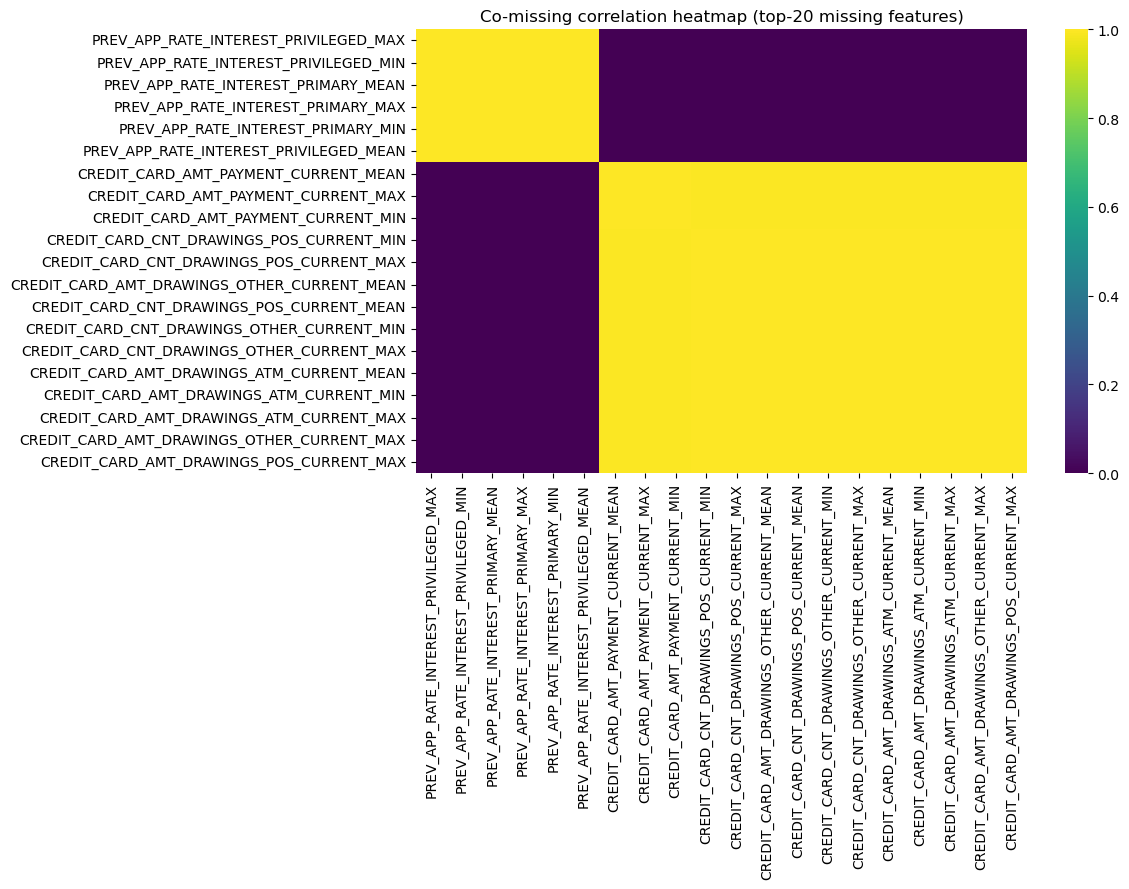

--- Predictive Power of Missing Data (Top 20 Features) ---


,feature,missing_rate,target_rate_if_missing,target_rate_if_not_missing,target_rate_diff,missing_indicator_auc
9,CREDIT_CARD_CNT_DRAWINGS_POS_CURRENT_MIN,0.801178,0.075837,0.100442,-0.024605,0.526406
10,CREDIT_CARD_CNT_DRAWINGS_POS_CURRENT_MAX,0.801178,0.075837,0.100442,-0.024605,0.526406
11,CREDIT_CARD_AMT_DRAWINGS_OTHER_CURRENT_MEAN,0.801178,0.075837,0.100442,-0.024605,0.526406
12,CREDIT_CARD_CNT_DRAWINGS_POS_CURRENT_MEAN,0.801178,0.075837,0.100442,-0.024605,0.526406
13,CREDIT_CARD_CNT_DRAWINGS_OTHER_CURRENT_MIN,0.801178,0.075837,0.100442,-0.024605,0.526406
14,CREDIT_CARD_CNT_DRAWINGS_OTHER_CURRENT_MAX,0.801178,0.075837,0.100442,-0.024605,0.526406
15,CREDIT_CARD_AMT_DRAWINGS_ATM_CURRENT_MEAN,0.801178,0.075837,0.100442,-0.024605,0.526406
16,CREDIT_CARD_AMT_DRAWINGS_ATM_CURRENT_MIN,0.801178,0.075837,0.100442,-0.024605,0.526406
17,CREDIT_CARD_AMT_DRAWINGS_ATM_CURRENT_MAX,0.801178,0.075837,0.100442,-0.024605,0.526406
18,CREDIT_CARD_AMT_DRAWINGS_OTHER_CURRENT_MAX,0.801178,0.075837,0.100442,-0.024605,0.526406


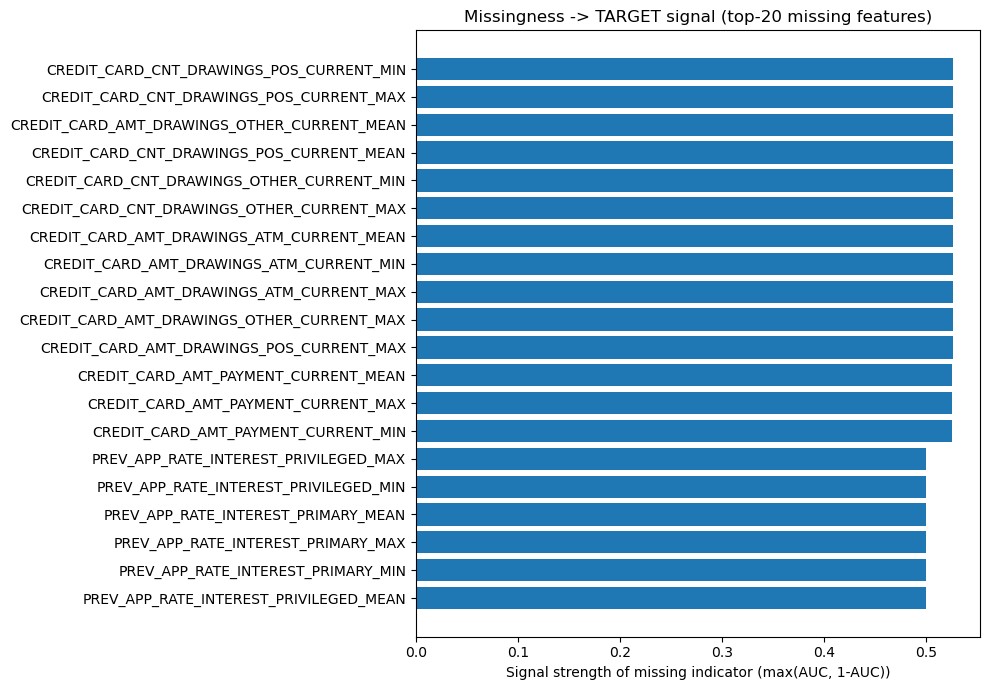

In [17]:
# --- EDA 4: Missingness Pattern Analysis ---
# Objective: Determine if data missingness is random (MCAR) or if it carries a predictive signal for default risk (MNAR).
from sklearn.metrics import roc_auc_score
# 1. Identify Top Missing Features
# Calculate the proportion of missing values for all features (excluding TARGET)
# and isolate the top 20 features with the highest missing rates.
missing_rank = train_joined.drop(columns=['TARGET'], errors='ignore').isna().mean().sort_values(ascending=False)
top_missing20 = missing_rank.head(20).index.tolist()

# 2. Co-missing Heatmap Analysis
# Objective: Identify groups of features that tend to be missing together 
# (e.g., if one building stat is missing, they all are). High correlation here 
# suggests we can drop redundant missing indicators later to save memory.
if len(top_missing20) >= 2:
    # Create a boolean mask (1 if missing, 0 if present) and calculate the correlation matrix
    co_missing = train_joined[top_missing20].isna().astype(int).corr()
    
    plt.figure(figsize=(12, 9))
    sns.heatmap(co_missing, cmap='viridis', vmin=0, vmax=1)
    plt.title('Co-missing correlation heatmap (top-20 missing features)')
    plt.tight_layout()
    plt.show()

# 3. Missingness as a Predictor (Signal Extraction)
# Objective: Determine if the mere fact that a value is missing correlates with the TARGET.
miss_signal_rows = []
y = train_joined['TARGET'].astype(int)

for c in top_missing20:
    # Create a binary indicator: 1 if missing, 0 if present
    m = train_joined[c].isna().astype(int)
    
    # Calculate average default rate when the feature is missing vs. when it is present
    rate_1 = float(y[m == 1].mean()) if (m == 1).any() else np.nan
    rate_0 = float(y[m == 0].mean()) if (m == 0).any() else np.nan
    
    auc = np.nan
    if m.nunique() > 1:
        # Calculate ROC AUC using the missing indicator to predict the target
        auc_raw = roc_auc_score(y, m)
        # Adjust AUC to be >= 0.5 to measure pure signal strength, regardless of correlation direction
        auc = max(auc_raw, 1 - auc_raw)
        
    miss_signal_rows.append({
        'feature': c,
        'missing_rate': float(m.mean()),
        'target_rate_if_missing': rate_1,
        'target_rate_if_not_missing': rate_0,
        # Calculate the impact: positive value means missingness increases default risk
        'target_rate_diff': rate_1 - rate_0 if pd.notna(rate_1) and pd.notna(rate_0) else np.nan,
        'missing_indicator_auc': auc,
    })

# 4. Reporting & Visualization
# Compile the results and sort by the strongest predictive signal
missingness_target_signal = pd.DataFrame(miss_signal_rows).sort_values(
    ['missing_indicator_auc', 'target_rate_diff'], ascending=[False, False]
)

print('--- Predictive Power of Missing Data (Top 20 Features) ---')
display(missingness_target_signal)

# Plot a horizontal bar chart of the missing indicator AUC scores
# We reverse the top 20 list (iloc[::-1]) so the highest AUC appears at the top of the chart
plot_df = missingness_target_signal.head(20).iloc[::-1]
plt.figure(figsize=(10, 7))
plt.barh(plot_df['feature'], plot_df['missing_indicator_auc'])
plt.xlabel('Signal strength of missing indicator (max(AUC, 1-AUC))')
plt.title('Missingness -> TARGET signal (top-20 missing features)')
plt.tight_layout()
plt.show()

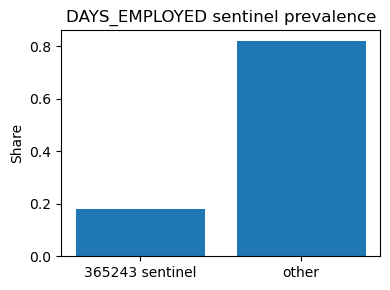

In [18]:
# EDA 5: DAYS_EMPLOYED sentinel value check 
if "DAYS_EMPLOYED" in train_joined.columns:
    sentinel_share = (train_joined["DAYS_EMPLOYED"] == 365243).mean()
    plt.figure(figsize=(4,3))
    plt.bar(["365243 sentinel", "other"], [sentinel_share, 1 - sentinel_share])
    plt.ylabel("Share")
    plt.title("DAYS_EMPLOYED sentinel prevalence")
    plt.tight_layout()
    plt.show()
else:
    print("DAYS_EMPLOYED not found in train_joined")

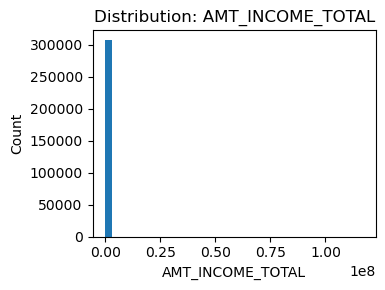

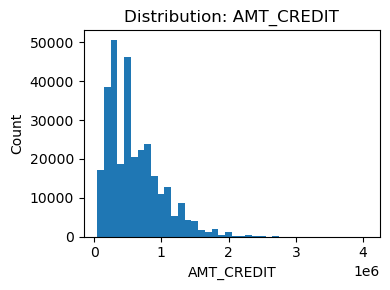

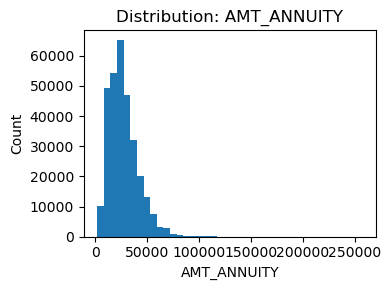

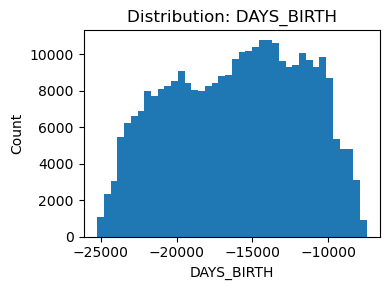

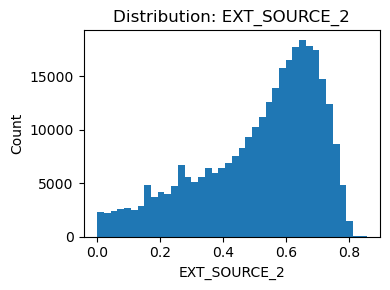

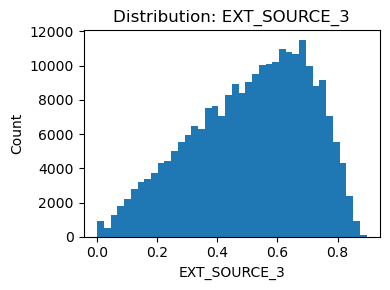

In [19]:
# EDA 6: Key numeric distributions 
num_candidates = ["AMT_INCOME_TOTAL","AMT_CREDIT","AMT_ANNUITY","DAYS_BIRTH","EXT_SOURCE_2","EXT_SOURCE_3"]
num_cols = [c for c in num_candidates if c in train_joined.columns]

for c in num_cols:
    s = train_joined[c].dropna()
    plt.figure(figsize=(4,3))
    plt.hist(s.values, bins=40)
    plt.xlabel(c)
    plt.ylabel("Count")
    plt.title(f"Distribution: {c}")
    plt.tight_layout()
    plt.show()

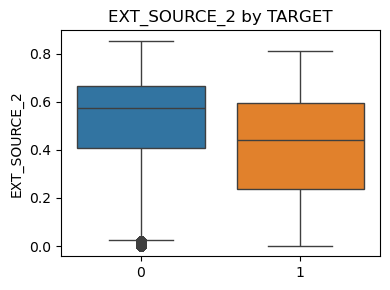

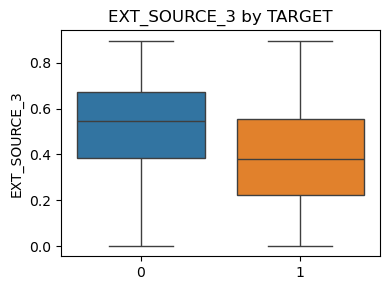

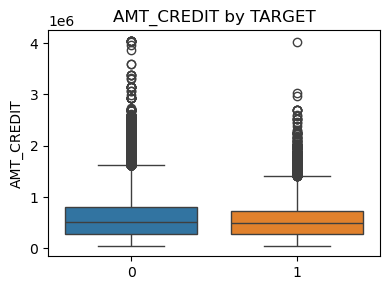

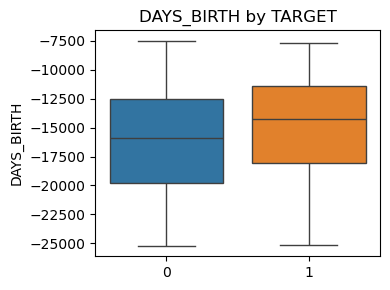

In [20]:
# EDA 7: Numeric vs TARGET (boxplot) for a few strong features
box_cols = [c for c in ["EXT_SOURCE_2","EXT_SOURCE_3","AMT_CREDIT","DAYS_BIRTH"] if c in train_joined.columns]

for c in box_cols:
    d0 = train_joined.loc[train_joined["TARGET"]==0, c].dropna()
    d1 = train_joined.loc[train_joined["TARGET"]==1, c].dropna()
    plt.figure(figsize=(4,3))
    sns.boxplot([d0.values, d1.values])
    plt.ylabel(c)
    plt.title(f"{c} by TARGET")
    plt.tight_layout()
    plt.show()

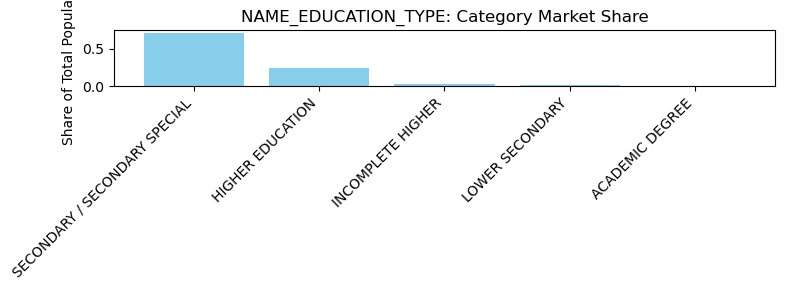

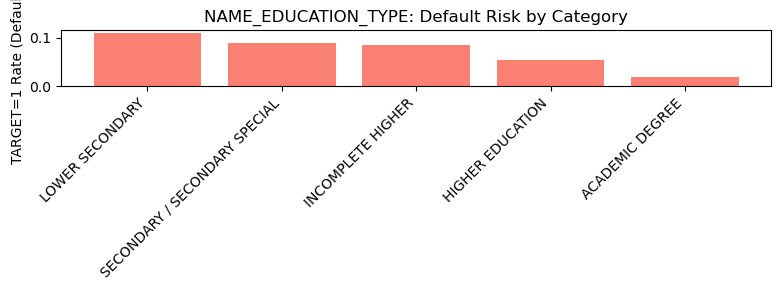

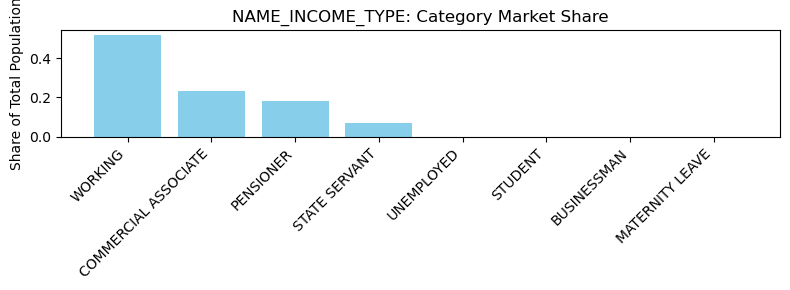

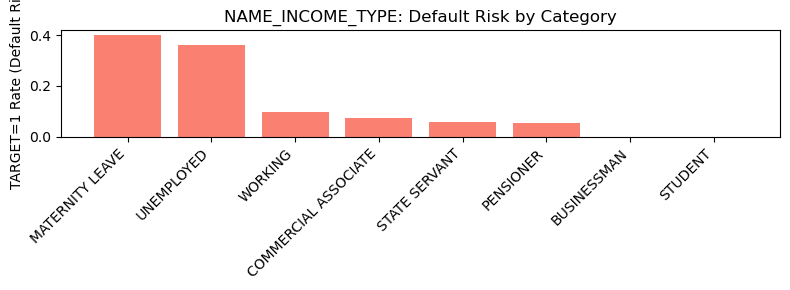

--- Numeric Feature Drift Report (Top 20 by Target Correlation) ---


,feature,psi,ks_stat,ks_pvalue,train_mean,test_mean
12,BUREAU_BUREAU_BALANCE_ROW_COUNT_MEAN,0.313084,0.245179,0.000000e+00,27.477237,36.304418
17,BUREAU_BUREAU_BALANCE_MONTHS_BALANCE_MEAN_MEAN,0.171562,0.150472,0.000000e+00,-20.984805,-17.683255
18,BUREAU_DAYS_CREDIT_MIN,0.029766,0.045133,5.574245e-65,-1762.374882,-1776.740217
3,CREDIT_CARD_CNT_DRAWINGS_ATM_CURRENT_MEAN,0.029205,0.062183,6.555850e-32,0.566241,0.440091
8,CREDIT_CARD_AMT_TOTAL_RECEIVABLE_MEAN,0.017633,0.061251,5.073344e-46,70985.788979,61804.250938
9,CREDIT_CARD_AMT_RECIVABLE_MEAN,0.017623,0.061277,4.647877e-46,70981.686227,61801.470342
10,CREDIT_CARD_AMT_RECEIVABLE_PRINCIPAL_MEAN,0.015688,0.061225,5.557890e-46,68748.971932,59929.496797
7,CREDIT_CARD_AMT_BALANCE_MEAN,0.015614,0.060979,1.287972e-45,71459.926952,62214.550683
4,CREDIT_CARD_CNT_DRAWINGS_CURRENT_MAX,0.013997,0.053222,7.615337e-35,6.803625,6.459917
5,BUREAU_DAYS_CREDIT_MEAN,0.010756,0.027809,6.264951e-25,-1083.047110,-1088.502807



--- Categorical Feature Drift Report ---


,feature,l1_share_shift,max_category_shift,n_categories_considered
0,NAME_CONTRACT_TYPE,0.172413,0.086207,2
10,WEEKDAY_APPR_PROCESS_START,0.090183,0.024764,7
7,NAME_FAMILY_STATUS,0.047033,0.023516,6
4,NAME_TYPE_SUITE,0.042879,0.014488,8
14,WALLSMATERIAL_MODE,0.040802,0.018235,8
15,EMERGENCYSTATE_MODE,0.037249,0.018625,3
13,HOUSETYPE_MODE,0.034418,0.017209,4
11,ORGANIZATION_TYPE,0.033849,0.010188,13
6,NAME_EDUCATION_TYPE,0.031156,0.013322,5
5,NAME_INCOME_TYPE,0.026227,0.013017,8


In [21]:
from scipy.stats import ks_2samp

# EDA 8: Categorical Profile & Distribution Drift

# --- A. Categorical Frequency + Target Positive Rate ---
cat_profile_cols = [c for c in ['NAME_EDUCATION_TYPE', 'NAME_INCOME_TYPE'] if c in train_joined.columns]

for c in cat_profile_cols:
    tmp = train_joined[[c, 'TARGET']].copy()
    tmp[c] = tmp[c].astype('object').fillna('Missing')

    # Lump rare categories into 'Other' to reduce visualization noise
    top = tmp[c].value_counts().head(12).index
    tmp[c] = tmp[c].where(tmp[c].isin(top), 'Other')

    # Aggregate by category: count occurrences and mean of TARGET (positive rate)
    prof = tmp.groupby(c)['TARGET'].agg(count='size', pos_rate='mean').reset_index()
    prof['share'] = prof['count'] / prof['count'].sum()
    
    # Plot 1: Category Market Share
    prof_share = prof.sort_values('share', ascending=False)
    plt.figure(figsize=(8, 3))
    plt.bar(prof_share[c].astype(str), prof_share['share'], color='skyblue')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Share of Total Population')
    plt.title(f'{c}: Category Market Share')
    plt.tight_layout()
    plt.show()

    # Plot 2: Default Risk (Positive Rate) by Category
    prof_risk = prof.sort_values('pos_rate', ascending=False)
    plt.figure(figsize=(8, 3))
    plt.bar(prof_risk[c].astype(str), prof_risk['pos_rate'], color='salmon')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('TARGET=1 Rate (Default Risk)')
    plt.title(f'{c}: Default Risk by Category')
    plt.tight_layout()
    plt.show()

# --- B. Train-vs-Test Drift: Numeric Features (PSI + KS Test) ---
def psi_score(expected, actual, bins=10):
    """
    Calculates the Population Stability Index (PSI) to measure distribution shift.
    expected: train array
    actual: test array
    """
    expected = np.asarray(expected, dtype=float)
    actual = np.asarray(actual, dtype=float)
    expected = expected[np.isfinite(expected)]
    actual = actual[np.isfinite(actual)]
    
    if len(expected) < 10 or len(actual) < 10:
        return np.nan

    # Create quantiles based on the expected (train) distribution
    q = np.linspace(0, 1, bins + 1)
    cuts = np.unique(np.quantile(expected, q))
    
    if len(cuts) < 3:
        return np.nan

    # Force outer edges to infinity to catch all outliers in the test set
    cuts[0], cuts[-1] = -np.inf, np.inf 

    exp_cnt, _ = np.histogram(expected, bins=cuts)
    act_cnt, _ = np.histogram(actual, bins=cuts)

    # Convert counts to percentages, clip to avoid division by zero or log(0)
    exp_pct = np.clip(exp_cnt / max(exp_cnt.sum(), 1), 1e-6, None)
    act_pct = np.clip(act_cnt / max(act_cnt.sum(), 1), 1e-6, None)
    
    # PSI Formula
    return float(np.sum((act_pct - exp_pct) * np.log(act_pct / exp_pct)))

# Identify valid numeric columns common to both train and test sets
num_candidates = [
    c for c in train_joined.select_dtypes(include=np.number).columns
    if c not in ['TARGET', 'SK_ID_CURR', '_is_train'] and c in test_joined.columns
]

# Prioritize the top 20 features with the highest absolute correlation to TARGET
if len(num_candidates) > 0:
    signal_order = train_joined[num_candidates].corrwith(train_joined['TARGET']).abs().sort_values(ascending=False)
    num_top = signal_order.head(min(20, len(signal_order))).index.tolist()
else:
    num_top = []

num_drift_rows = []
for c in num_top:
    tr = train_joined[c].replace([np.inf, -np.inf], np.nan).dropna()
    te = test_joined[c].replace([np.inf, -np.inf], np.nan).dropna()
    
    if len(tr) < 20 or len(te) < 20:
        continue
        
    ks_stat, ks_p = ks_2samp(tr, te)
    num_drift_rows.append({
        'feature': c,
        'psi': psi_score(tr, te, bins=10),
        'ks_stat': float(ks_stat),
        'ks_pvalue': float(ks_p),
        'train_mean': float(tr.mean()),
        'test_mean': float(te.mean()),
    })

numeric_drift_report = pd.DataFrame(num_drift_rows).sort_values(['psi', 'ks_stat'], ascending=False)
print('--- Numeric Feature Drift Report (Top 20 by Target Correlation) ---')
display(numeric_drift_report.head(20))

# --- C. Train-vs-Test Drift: Categorical Share Shift (L1 Distance) ---
cat_candidates = [
    c for c in train_joined.select_dtypes(include=['object', 'category']).columns
    if c in test_joined.columns
]
cat_drift_rows = []

for c in cat_candidates:
    tr = train_joined[c].fillna('Missing').astype(str)
    te = test_joined[c].fillna('Missing').astype(str)

    # Align categories by top 12 in train
    top = tr.value_counts().head(12).index
    tr2 = tr.where(tr.isin(top), 'Other')
    te2 = te.where(te.isin(top), 'Other')

    tr_share = tr2.value_counts(normalize=True)
    te_share = te2.value_counts(normalize=True)
    
    # Ensure both series have the exact same index (categories)
    all_idx = tr_share.index.union(te_share.index)
    tr_share = tr_share.reindex(all_idx, fill_value=0)
    te_share = te_share.reindex(all_idx, fill_value=0)
    
    # Calculate drift metrics
    l1_shift = float((tr_share - te_share).abs().sum())
    max_shift = float((tr_share - te_share).abs().max())

    cat_drift_rows.append({
        'feature': c,
        'l1_share_shift': l1_shift,
        'max_category_shift': max_shift,
        'n_categories_considered': int(len(all_idx)),
    })

categorical_drift_report = pd.DataFrame(cat_drift_rows).sort_values('l1_share_shift', ascending=False)
print('\n--- Categorical Feature Drift Report ---')
display(categorical_drift_report.head(20))

In [22]:
# 1. Columns that should NEVER be used as predictive features:
# TARGET: The label we are trying to predict (causes data leakage if kept)
# SK_ID_CURR: The applicant ID (adds meaningless noise to a tree model)
# _is_train: A helper flag used during previous merge steps
DROP_COLS = ["TARGET", "SK_ID_CURR", "_is_train"]

# 2. Drop ids/labels if present
X_train_raw = train_joined.drop(columns=[c for c in DROP_COLS if c in train_joined.columns])
X_test_raw  = test_joined.drop(columns=[c for c in DROP_COLS if c in test_joined.columns], errors="ignore")

# 3. Create Target Vector (y)
y_train = train_joined["TARGET"].astype("int8") # keep small dtype for memory

# 4. Verification Check
shape_report = pd.DataFrame({
    "object": ["X_train_raw", "y_train", "X_test_raw"],
    "shape":  [X_train_raw.shape, y_train.shape, X_test_raw.shape],
})

print("--- Final Matrix Shapes Before Modeling ---")
display(shape_report)

--- Final Matrix Shapes Before Modeling ---


,object,shape
0,X_train_raw,"(307511, 891)"
1,y_train,"(307511,)"
2,X_test_raw,"(48744, 891)"


In [23]:
# Data Type Distribution Summary to verify the composition of our feature matrix.
dtype_counts = (
    X_train_raw.dtypes.astype(str).str.split("(", n=1).str[0]
    .value_counts()
)

print("--- Feature Matrix Data Type Summary ---")
display(dtype_counts.rename_axis("dtype_group").reset_index(name="count"))


--- Feature Matrix Data Type Summary ---


,dtype_group,count
0,float64,836
1,int64,39
2,object,16


In [24]:
from sklearn.model_selection import train_test_split
# 1. Global Random Seed Setup
random_state = 42
np.random.seed(random_state)

# 2. Stratified Data Splitting
X_tr_raw, X_val_raw, y_tr, y_val = train_test_split(
    X_train_raw, y_train,
    test_size=0.2,
    random_state=random_state,
    stratify=y_train
)

# 3. Verification & Reporting
split_report = pd.DataFrame({
    "metric": [
        "X_tr_raw_shape", 
        "X_val_raw_shape", 
        "X_test_raw_shape", 
        "y_tr_pos_rate", 
        "y_val_pos_rate"
    ],
    "value": [
        X_tr_raw.shape, 
        X_val_raw.shape, 
        X_test_raw.shape, 
        float(np.mean(y_tr)), 
        float(np.mean(y_val))
    ]
})

print("--- Train/Validation Split Summary ---")
display(split_report)

--- Train/Validation Split Summary ---


,metric,value
0,X_tr_raw_shape,"(246008, 891)"
1,X_val_raw_shape,"(61503, 891)"
2,X_test_raw_shape,"(48744, 891)"
3,y_tr_pos_rate,0.080729
4,y_val_pos_rate,0.080728


,bucket,n_features,avg_missing_rate
0,0-5%,63,0.000325
1,5-20%,590,0.073462
2,20-60%,42,0.469369
3,60-100%,196,0.725647


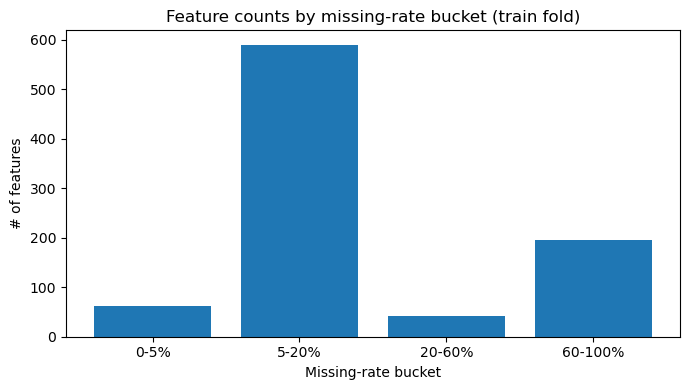

In [25]:
# Missing-rate buckets on train fold
miss_rate = X_tr_raw.isna().mean().sort_values(ascending=False)

bins = [0, 0.05, 0.20, 0.60, 1.0]
labels = ["0-5%", "5-20%", "20-60%", "60-100%"]

bucket = pd.cut(miss_rate, bins=bins, labels=labels, include_lowest=True)

bucket_summary = (
    pd.DataFrame({"missing_rate": miss_rate, "bucket": bucket})
      .groupby("bucket")
      .agg(n_features=("missing_rate", "size"),
           avg_missing_rate=("missing_rate", "mean"))
      .reset_index()
)

display(bucket_summary)

plt.figure(figsize=(7, 4))
plt.bar(bucket_summary["bucket"].astype(str), bucket_summary["n_features"])
plt.xlabel("Missing-rate bucket")
plt.ylabel("# of features")
plt.title("Feature counts by missing-rate bucket (train fold)")
plt.tight_layout()
plt.show()


# Feature Selection & Engineering

In [59]:
log_dir = './log'
def export_feature_log(step_name, dropped_cols, remaining_count):
    """
    Exports a list of dropped features to a CSV file in the /log folder.
    """
    log_filename = f"{log_dir}/feature_drop_{step_name}.csv"
    
    log_df = pd.DataFrame({
        'dropped_feature': dropped_cols,
        'step': step_name,
        'total_remaining_after_this_step': remaining_count
    })
    
    log_df.to_csv(log_filename, index=False)
    print(f"Log saved: {log_filename} ({len(dropped_cols)} features removed)")

In [ ]:
THRESH = 0.65

# decide drops using TRAIN fold only to avoid leakage
drop_cols = X_tr_raw.columns[X_tr_raw.isna().mean() > THRESH].tolist()

# apply the same drops to all splits
X_tr_step  = X_tr_raw.drop(columns=drop_cols).copy()
X_val_step = X_val_raw.drop(columns=drop_cols).copy()
X_test_step= X_test_raw.drop(columns=drop_cols).copy()

dropped_high_missing_cols = drop_cols  # keep for audit


audit_report = pd.DataFrame({
    "metric": ["threshold", "n_cols_dropped", "tr_shape_after", "val_shape_after", "test_shape_after"],
    "value":  [THRESH, len(drop_cols), X_tr_step.shape, X_val_step.shape, X_test_step.shape],
})

print("\n--- High Missing Removal Audit ---")
display(audit_report)

export_feature_log(
    step_name="high_missing_removal", 
    dropped_cols=drop_cols, 
    remaining_count=X_tr_step.shape[1]
)


--- High Missing Removal Audit ---


,metric,value
0,threshold,0.65
1,n_cols_dropped,196
2,tr_shape_after,"(246008, 695)"
3,val_shape_after,"(61503, 695)"
4,test_shape_after,"(48744, 695)"


Log saved: ./log/feature_drop_high_missing_removal.csv (196 features removed)


In [27]:
# Data Drift Feature Selection
PSI_THRESHOLD = 0.15
L1_SHIFT_THRESHOLD = 0.15

print(f"\n--- Data Drift Drops ---")
print(f"Applying Drift Thresholds: PSI > {PSI_THRESHOLD}, L1 Shift > {L1_SHIFT_THRESHOLD}")

# 1. Identify Numeric and Categorical Features with High Drift
if not numeric_drift_report.empty:
    high_drift_num = numeric_drift_report[numeric_drift_report['psi'] > PSI_THRESHOLD]['feature'].tolist()
else:
    high_drift_num = []

if not categorical_drift_report.empty:
    high_drift_cat = categorical_drift_report[categorical_drift_report['l1_share_shift'] > L1_SHIFT_THRESHOLD]['feature'].tolist()
else:
    high_drift_cat = []

# Combine all features flagged for removal
features_to_drop_drift = high_drift_num + high_drift_cat

print(f"\nFound {len(high_drift_num)} numeric and {len(high_drift_cat)} categorical features exceeding drift limits.")

if len(features_to_drop_drift) > 0:
    # 2. Safely Drop Features from all three working sets
    X_tr_step = X_tr_step.drop(columns=features_to_drop_drift, errors='ignore')
    X_val_step = X_val_step.drop(columns=features_to_drop_drift, errors='ignore')
    X_test_step = X_test_step.drop(columns=features_to_drop_drift, errors='ignore')
    
    dropped_drift_cols = features_to_drop_drift # Keep for audit
    
    print(f"\nSuccessfully dropped drift features.")
    print("The drifting feature was:", features_to_drop_drift)
    # Final Reporting
    display(pd.DataFrame({
        "metric": ["drift_cols_flagged", "tr_shape_final", "val_shape_final", "test_shape_final"],
        "value":  [len(features_to_drop_drift), X_tr_step.shape, X_val_step.shape, X_test_step.shape],
    }))
else:
    print("\nNo features exceeded the drift thresholds. Matrix shapes remain unchanged.")
    dropped_drift_cols = []


--- Data Drift Drops ---
Applying Drift Thresholds: PSI > 0.15, L1 Shift > 0.15

Found 2 numeric and 1 categorical features exceeding drift limits.

Successfully dropped drift features.
The drifting feature was: ['BUREAU_BUREAU_BALANCE_ROW_COUNT_MEAN', 'BUREAU_BUREAU_BALANCE_MONTHS_BALANCE_MEAN_MEAN', 'NAME_CONTRACT_TYPE']


,metric,value
0,drift_cols_flagged,3
1,tr_shape_final,"(246008, 694)"
2,val_shape_final,"(61503, 694)"
3,test_shape_final,"(48744, 694)"


In [62]:
export_feature_log(
        step_name="data_drift_removal", 
        dropped_cols=dropped_drift_cols, 
        remaining_count=X_tr_step.shape[1]
    )

Log saved: ./log/feature_drop_data_drift_removal.csv (3 features removed)


In [28]:
# Feature Family Grouping for Domain-Specific Processing

# 1. Base Feature Types
cat_cols = X_tr_step.select_dtypes(include=["object", "category"]).columns.tolist()  
num_cols = X_tr_step.select_dtypes(include=np.number).columns.tolist()

# 2. Define Domain-Specific Candidate Lists
SOCIAL_CANDIDATES = [
    "OBS_30_CNT_SOCIAL_CIRCLE", "DEF_30_CNT_SOCIAL_CIRCLE",
    "OBS_60_CNT_SOCIAL_CIRCLE", "DEF_60_CNT_SOCIAL_CIRCLE",
]

BUREAU_CANDIDATES = [
    "AMT_REQ_CREDIT_BUREAU_HOUR", "AMT_REQ_CREDIT_BUREAU_DAY", "AMT_REQ_CREDIT_BUREAU_WEEK",
    "AMT_REQ_CREDIT_BUREAU_MON", "AMT_REQ_CREDIT_BUREAU_QRT", "AMT_REQ_CREDIT_BUREAU_YEAR",
]

# 3. Defensive Extraction
# We only keep the columns that actually survived the previous missing-value and drift filters.
social_cols = [c for c in SOCIAL_CANDIDATES if c in X_tr_step.columns]
bureau_cols = [c for c in BUREAU_CANDIDATES if c in X_tr_step.columns]

# Phone change is a highly predictive feature in Home Credit; isolate it safely.
phone_col = "DAYS_LAST_PHONE_CHANGE" if "DAYS_LAST_PHONE_CHANGE" in X_tr_step.columns else None

# 4. Feature Family Audit Report
feature_groups_report = pd.DataFrame({
    "group": ["cat_cols", "num_cols", "social_cols", "bureau_cols", "phone_col_present"],
    "count": [len(cat_cols), len(num_cols), len(social_cols), len(bureau_cols), int(phone_col is not None)],
})

print("--- Feature Family Audit ---")
display(feature_groups_report)

--- Feature Family Audit ---


,group,count
0,cat_cols,14
1,num_cols,680
2,social_cols,4
3,bureau_cols,6
4,phone_col_present,1


In [29]:
# Add Missingness Indicators to Feature Family

# 1. Create fresh copies to avoid SettingWithCopy warnings
X_tr_step2 = X_tr_step.copy()
X_val_step2 = X_val_step.copy()
X_test_step2 = X_test_step.copy()

splits = [X_tr_step2, X_val_step2, X_test_step2]
indicator_cols = []

# Define which indicators will be created based on available columns
if social_cols: indicator_cols.append("SOCIAL_CIRCLE_MISSING")
if bureau_cols: indicator_cols.append("CREDIT_BUREAU_MISSING")
if phone_col:   indicator_cols.append("DAYS_LAST_PHONE_CHANGE_MISSING")

# 2. Apply all transformations in a single loop (more pythonic and efficient)
for df_ in splits:
    # Aggregated missing signal: 1 if ANY social feature is missing, else 0
    if social_cols:
        df_["SOCIAL_CIRCLE_MISSING"] = df_[social_cols].isna().any(axis=1).astype("uint8")
        
    # Aggregated missing signal: 1 if ANY credit bureau feature is missing, else 0
    if bureau_cols:
        df_["CREDIT_BUREAU_MISSING"] = df_[bureau_cols].isna().any(axis=1).astype("uint8")
        
    # Single feature missing signal
    if phone_col:
        df_["DAYS_LAST_PHONE_CHANGE_MISSING"] = df_[phone_col].isna().astype("uint8")

# 3. Audit Report
# Verify how many positive flags (1s) were generated across the datasets
indicator_audit = pd.DataFrame({
    "indicator": indicator_cols,
    "tr_sum":  [int(X_tr_step2[c].sum()) for c in indicator_cols],
    "val_sum": [int(X_val_step2[c].sum()) for c in indicator_cols],
    "test_sum":[int(X_test_step2[c].sum()) for c in indicator_cols],
})

print("--- Missingness Indicator Flags Created ---")
display(indicator_audit)

--- Missingness Indicator Flags Created ---


,indicator,tr_sum,val_sum,test_sum
0,SOCIAL_CIRCLE_MISSING,811,210,29
1,CREDIT_BUREAU_MISSING,33244,8275,6049
2,DAYS_LAST_PHONE_CHANGE_MISSING,1,0,0


In [ ]:
# Missingness Signal Lift Analysis (Train Fold Only)

# 1. Align the target vector with the current training fold index
# Converting to numpy array drastically speeds up the boolean masking operations below.
y = y_train.loc[X_tr_step2.index].astype(int).to_numpy()

lift_rows = []

# 2. Iterate through all features to calculate the "Lift" of missingness
for c in X_tr_step2.columns:
    # Create a boolean mask for missing values in this column
    is_missing = X_tr_step2[c].isna().to_numpy()
    
    # Calculate the missing rate
    missing_rate = is_missing.mean()
    
    # Calculate Target Rate (Default Rate) conditionally
    # We use conditional checks to prevent ZeroDivision/Runtime warnings on columns with 0% missing data
    rate_if_missing = y[is_missing].mean() if is_missing.any() else np.nan
    rate_if_present = y[~is_missing].mean() if (~is_missing).any() else np.nan
    
    lift_rows.append({
        "feature": c,
        "missing_rate": missing_rate,
        "target_rate_if_missing": rate_if_missing,
        "target_rate_if_present": rate_if_present,
        # 'diff' represents how much higher (or lower) the default risk is when the data is missing
        "diff": rate_if_missing - rate_if_present if pd.notna(rate_if_missing) else np.nan
    })

# 3. Sort and Display
# Features at the top are those where a missing value strongly implies a HIGHER risk of default.
lift = pd.DataFrame(lift_rows).sort_values("diff", ascending=False).reset_index(drop=True)

print("--- Default Risk Lift by Missingness ---")
display(lift.head(30))

--- Default Risk Lift by Missingness ---


,feature,missing_rate,target_rate_if_missing,target_rate_if_present,diff
0,BUREAU_DAYS_ENDDATE_FACT_MIN,0.250785,0.104919,0.072632,0.032287
1,BUREAU_DAYS_ENDDATE_FACT_MEAN,0.250785,0.104919,0.072632,0.032287
2,BUREAU_DAYS_ENDDATE_FACT_MAX,0.250785,0.104919,0.072632,0.032287
3,AMT_REQ_CREDIT_BUREAU_HOUR,0.135134,0.103387,0.077189,0.026198
4,AMT_REQ_CREDIT_BUREAU_DAY,0.135134,0.103387,0.077189,0.026198
5,AMT_REQ_CREDIT_BUREAU_WEEK,0.135134,0.103387,0.077189,0.026198
6,AMT_REQ_CREDIT_BUREAU_MON,0.135134,0.103387,0.077189,0.026198
7,AMT_REQ_CREDIT_BUREAU_QRT,0.135134,0.103387,0.077189,0.026198
8,AMT_REQ_CREDIT_BUREAU_YEAR,0.135134,0.103387,0.077189,0.026198
9,BUREAU_DAYS_CREDIT_ENDDATE_MAX,0.150637,0.101436,0.077057,0.024379


# Handle Missing Values

## Imputation Strategy Sensitivity 

Compare two train-fit numeric imputation strategies (median vs constant-0) using a lightweight validation model.

In [31]:
# Define feature groups that MUST be filled with 0 (No Record / Did Not Happen)
cols_to_zero = []
if social_cols: cols_to_zero.extend(social_cols)
if bureau_cols: cols_to_zero.extend(bureau_cols)
if phone_col:   cols_to_zero.append(phone_col)

In [32]:
# Correct DAYS_EMPLOYED anomalies
for df_ in [X_tr_step2, X_val_step2, X_test_step2]:
    if "DAYS_EMPLOYED" in df_.columns:
        # 1. Capture the signal: Create a boolean flag (Optional but highly recommended)"
        df_["DAYS_EMPLOYED_ANOMALY"] = (df_["DAYS_EMPLOYED"] == 365243)
        
        # 2. Neutralize the poison: Replace 365243 with NaN 
        df_["DAYS_EMPLOYED"] = df_["DAYS_EMPLOYED"].replace({365243: np.nan})

print("Anomaly handling complete")

Anomaly handling complete


In [33]:
# Grouped Imputation Strategy Sensitivity Analysis
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 1. Define candidates and target columns
group_candidates = ['NAME_EDUCATION_TYPE', 'NAME_INCOME_TYPE', 'OCCUPATION_TYPE', 'CODE_GENDER']
valid_groups = [c for c in group_candidates if c in X_tr_step2.columns]

num_cols_with_nans = [c for c in num_cols if c not in cols_to_zero and X_tr_step2[c].isna().sum() > 0]
missing_rank = X_tr_step2[num_cols_with_nans].isna().mean().sort_values(ascending=False)
comp_cols = missing_rank.head(min(100, len(missing_rank))).index.tolist()

# 2. Subsample for Speed (80k rows)
max_rows = min(80000, len(X_tr_step2))
rng = np.random.default_rng(random_state)
row_idx = rng.choice(X_tr_step2.index.to_numpy(), size=max_rows, replace=False)

# Make sure all valid groups are in the subsample
Xtr_sub = X_tr_step2.loc[row_idx, comp_cols + valid_groups]
ytr_sub = pd.Series(y_tr, index=X_tr_step2.index).loc[row_idx]
Xval_sub = X_val_step2[comp_cols + valid_groups]
yval_sub = pd.Series(y_val, index=X_val_step2.index)

# 3. Mapping function 
def fast_grouped_imputation(df_t, df_v, group_key, target_cols, strat):
    t_imp, v_imp = pd.DataFrame(index=df_t.index), pd.DataFrame(index=df_v.index)
    for col in target_cols:
        if strat == 'median':
            grp_st, glb_st = df_t.groupby(group_key)[col].median(), df_t[col].median()
        else: # mean
            grp_st, glb_st = df_t.groupby(group_key)[col].mean(), df_t[col].mean()
            
        t_mapped, v_mapped = df_t[group_key].map(grp_st), df_v[group_key].map(grp_st)
        t_imp[col] = df_t[col].fillna(t_mapped).fillna(glb_st).fillna(0)
        v_imp[col] = df_v[col].fillna(v_mapped).fillna(glb_st).fillna(0)
    return t_imp, v_imp

# 4. Run the Grid Search
rows = []
strategies = ['median', 'mean']
clf = LogisticRegression(max_iter=350, class_weight='balanced', solver='lbfgs', n_jobs=-1)

print(f"Testing {len(valid_groups)} grouping features x {len(strategies)} strategies...")

# Test all Group + Strategy combinations
for grp in valid_groups:
    for strat in strategies:
        X_t, X_v = fast_grouped_imputation(Xtr_sub, Xval_sub, grp, comp_cols, strat)
        pipe = Pipeline([('scaler', StandardScaler()), ('clf', clf)])
        pipe.fit(X_t, ytr_sub)
        auc = roc_auc_score(yval_sub, pipe.predict_proba(X_v)[:, 1])
        rows.append({'Imputation_Type': f"{grp} + {strat.capitalize()}", 'val_auc': float(auc)})

# Test the best combination
X_t_glob = Xtr_sub[comp_cols].fillna(Xtr_sub[comp_cols].median())
X_v_glob = Xval_sub[comp_cols].fillna(Xtr_sub[comp_cols].median())
pipe.fit(X_t_glob, ytr_sub)
rows.append({'Imputation_Type': "Global_Median_Baseline (No Grouping)", 'val_auc': float(roc_auc_score(yval_sub, pipe.predict_proba(X_v_glob)[:, 1]))})

# 5. Display the ultimate scoreboard
imputation_scoreboard = pd.DataFrame(rows).sort_values('val_auc', ascending=False).reset_index(drop=True)
print("\n--- Ultimate Imputation Scoreboard ---")
display(imputation_scoreboard)

Testing 4 grouping features x 2 strategies...

--- Ultimate Imputation Scoreboard ---


,Imputation_Type,val_auc
0,OCCUPATION_TYPE + Median,0.701886
1,CODE_GENDER + Median,0.700218
2,NAME_INCOME_TYPE + Median,0.699069
3,OCCUPATION_TYPE + Mean,0.697287
4,Global_Median_Baseline (No Grouping),0.696289
5,CODE_GENDER + Mean,0.696242
6,NAME_EDUCATION_TYPE + Median,0.694470
7,NAME_INCOME_TYPE + Mean,0.694338
8,NAME_EDUCATION_TYPE + Mean,0.692746


In [34]:
# Execute the Winning Imputation Strategy on Full Data

# 1. Extract the winning strategy from the 2D scoreboard
winning_strategy_full = imputation_scoreboard.loc[0, 'Imputation_Type']
cols_to_impute_full = [c for c in num_cols if c not in cols_to_zero]


group_col, stat_cap = winning_strategy_full.split(" + ")
winning_stat = stat_cap.lower()  # 'median' or 'mean'

print(f"Applying Winning Strategy ({winning_stat.capitalize()}) grouped by '{group_col}' to full matrices")

# Apply strict train-learned mapping to all splits
for col in cols_to_impute_full:
    
    # Step 1: Learn statistics strictly from the Training fold
    if winning_stat == 'median':
        group_stats = X_tr_step2.groupby(group_col)[col].median()
        global_stat = X_tr_step2[col].median()
    else: # mean
        group_stats = X_tr_step2.groupby(group_col)[col].mean()
        global_stat = X_tr_step2[col].mean()
        
    # Step 2: Apply the learned mapping to Train, Val, and Test folds sepreately
    for df_ in [X_tr_step2, X_val_step2, X_test_step2]:
        # Map the grouped stats based on the individual's group_col value
        mapped_vals = df_[group_col].map(group_stats)
        
        # Fill logic: Try Grouped Stat -> Fallback to Global Stat -> Fallback to 0 
        df_[col] = df_[col].fillna(mapped_vals).fillna(global_stat).fillna(0)

# 2. Finalize the 0-fill columns (Bureau & Social Families)
for df_ in [X_tr_step2, X_val_step2, X_test_step2]:
    if cols_to_zero:
        df_[cols_to_zero] = df_[cols_to_zero].fillna(0)

# 3. Final Audit
print("\n--- Imputation Complete! ---")
print(f"Remaining NaNs in numeric columns (Train): {X_tr_step2[num_cols].isna().sum().sum()}")
print(f"Remaining NaNs in numeric columns (Val):   {X_val_step2[num_cols].isna().sum().sum()}")
print(f"Remaining NaNs in numeric columns (Test):  {X_test_step2[num_cols].isna().sum().sum()}")

Applying Winning Strategy (Median) grouped by 'OCCUPATION_TYPE' to full matrices...

--- Imputation Complete! ---
Remaining NaNs in numeric columns (Train): 0
Remaining NaNs in numeric columns (Val):   0
Remaining NaNs in numeric columns (Test):  0


In [35]:
# Categorical Imputation

# 1. Create fresh copies from the previously PERFECTED numeric matrices
X_tr_step3 = X_tr_step2.copy()
X_val_step3 = X_val_step2.copy()
X_test_step3 = X_test_step2.copy()

splits = [X_tr_step3, X_val_step3, X_test_step3]

# 2. Categoricals: Explicit missing token (Applied to all splits)
# This preserves the missingness signal for tree models and satisfies SMOTENC.
if cat_cols:
    for df_ in splits:
        for col in cat_cols:
            # If the column is already a pandas 'category' dtype, 
            # we must add "Missing" to its categories BEFORE filling NaNs.
            if df_[col].dtype.name == 'category':
                if "Missing" not in df_[col].cat.categories:
                    df_[col] = df_[col].cat.add_categories("Missing")
            
            # Fill NaNs with our explicit textual token
            df_[col] = df_[col].fillna("Missing")

# 3. Ultimate Final Audit
# Verify that absolutely ZERO NaNs remain across both numeric and categorical spaces.
audit_report = pd.DataFrame({
    "dataset": ["train", "val", "test"],
    "missing_total": [
        int(X_tr_step3.isna().sum().sum()),
        int(X_val_step3.isna().sum().sum()),
        int(X_test_step3.isna().sum().sum()),
    ],
})

print("\n--- Ultimate Matrix Audit Report ---")
display(audit_report)


--- Ultimate Matrix Audit Report ---


,dataset,missing_total
0,train,0
1,val,0
2,test,0


# Outlier Handling

In [36]:
# Using Dynamic Winsorization (Clipping)

# Ignore warning fot not convergence
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)


# 1. Base copies for this step to preserve previous matrix states
X_tr_step4 = X_tr_step3.copy()
X_val_step4 = X_val_step3.copy()
X_test_step4 = X_test_step3.copy()

# 2. Smart Feature Filtering
# We only want to clip continuous numeric columns. We explicitly exclude missing flags, 
# document flags, and binary/low-cardinality columns where clipping makes no mathematical sense.
num_cols = X_tr_step3.select_dtypes(include=np.number).columns
continuous_candidates = [
    c for c in num_cols
    if not c.endswith("_MISSING")
    and not c.startswith("FLAG_")
    and not c.startswith("FLAG_DOCUMENT_")
    and X_tr_step3[c].nunique(dropna=True) > 2
]

print(f"Identified {len(continuous_candidates)} continuous features for Winsorization.")

# 3. Sensitivity Setup: High-Variance Subsampling
# To save runtime, we evaluate the clipping strategy on the top 120 highest-variance features
num_base = X_tr_step3[continuous_candidates]
var_rank = num_base.var().sort_values(ascending=False)
sens_cols = var_rank.head(min(120, len(var_rank))).index.tolist()

# Row subsample for runtime safety (80,000 rows max)
max_rows = min(80000, len(num_base))
rng = np.random.default_rng(random_state) # Uses your globally defined random_state
idx = rng.choice(num_base.index.to_numpy(), size=max_rows, replace=False)

# Create the subset matrices for evaluation
Xtr_no = num_base.loc[idx, sens_cols]
Xval_no = X_val_step3[sens_cols]
ytr_s = pd.Series(y_tr, index=X_tr_step3.index).loc[idx]
yval_s = pd.Series(y_val, index=X_val_step3.index)

# 4. Define Evaluation Pipeline
# We use Logistic Regression because linear models are highly sensitive to outliers, 
# making it the perfect "detector" for finding the best clipping bounds.
model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=350, class_weight='balanced', solver='lbfgs')),
])

# Baseline evaluation: No clipping
model.fit(Xtr_no, ytr_s)
auc_no_clip = float(roc_auc_score(yval_s, model.predict_proba(Xval_no)[:, 1]))

# 5. Grid Search for Candidate Clipping Quantiles
quantile_grid = [
    # 1. Right-Tail Only
    (0.00, 0.999), 
    (0.00, 0.995), 
    (0.00, 0.99),  
    (0.00, 0.98),  
    (0.00, 0.95),  
    # 2.Conservative Symmetric
    (0.001, 0.999),
    (0.0025, 0.9975),
    (0.005, 0.995),
    (0.01, 0.99),
    (0.02, 0.98),
    (0.05, 0.95), 
    # 3. Asymmetric Tweaks
    (0.001, 0.99), 
    (0.005, 0.98), 
    # 4. Left-Tail Only
    (0.01, 1.00),
    (0.05, 1.00)
]

search_rows = []


for ql, qh in quantile_grid:
    Xtr_q = Xtr_no.copy()
    Xval_q = Xval_no.copy()

    # CRITICAL FIX: Extract quantiles as Pandas Series, not raw .values arrays.
    # This ensures exact column-name alignment during the clip() operation.
    lower_bounds = X_tr_step3[sens_cols].quantile(ql)
    upper_bounds = X_tr_step3[sens_cols].quantile(qh)

    Xtr_q = Xtr_q.clip(lower=lower_bounds, upper=upper_bounds, axis=1)
    Xval_q = Xval_q.clip(lower=lower_bounds, upper=upper_bounds, axis=1)

    # Evaluate the clipped matrix
    model.fit(Xtr_q, ytr_s)
    auc_q = float(roc_auc_score(yval_s, model.predict_proba(Xval_q)[:, 1]))

    # Track how aggressively the data is being altered
    train_change_rate = (Xtr_no != Xtr_q).sum().sum() / (Xtr_no.shape[0] * Xtr_no.shape[1])
    
    search_rows.append({
        'lower_q': ql,
        'upper_q': qh,
        'val_auc': auc_q,
        'train_cell_change_rate': train_change_rate,
    })

# 6. Extract the Winning Quantiles
outlier_quantile_search = pd.DataFrame(search_rows).sort_values('val_auc', ascending=False).reset_index(drop=True)
best_lower_q = float(outlier_quantile_search.loc[0, 'lower_q'])
best_upper_q = float(outlier_quantile_search.loc[0, 'upper_q'])
auc_best_clip = float(outlier_quantile_search.loc[0, 'val_auc'])

# 7. Apply the Best Bounds to All Full Matrices
best_lo_series = X_tr_step3[continuous_candidates].quantile(best_lower_q)
best_hi_series = X_tr_step3[continuous_candidates].quantile(best_upper_q)

for df_ in (X_tr_step4, X_val_step4, X_test_step4):
    df_[continuous_candidates] = df_[continuous_candidates].clip(
        lower=best_lo_series, 
        upper=best_hi_series, 
        axis=1
    )

# 8. Final Reporting

impact_rate_best = (X_tr_step3[continuous_candidates] != X_tr_step4[continuous_candidates]).sum().sum() / (X_tr_step3.shape[0] * len(continuous_candidates))

outlier_strategy_comparison = pd.DataFrame([
    {'strategy': 'No Clipping (Baseline)', 'val_auc': auc_no_clip, 'train_change_rate': 0.0},
    {'strategy': f'Best Clipping (Q{best_lower_q} to Q{best_upper_q})', 'val_auc': auc_best_clip, 'train_change_rate': impact_rate_best},
]).sort_values('val_auc', ascending=False).reset_index(drop=True)

print("\n--- Outlier Quantile Grid Search Results ---")
display(outlier_quantile_search)

print("\n--- Final Winsorization Strategy Comparison ---")
display(outlier_strategy_comparison)

Identified 588 continuous features for Winsorization.

--- Outlier Quantile Grid Search Results ---


,lower_q,upper_q,val_auc,train_cell_change_rate
0,0.0500,0.9500,0.708085,0.080050
1,0.0000,0.9500,0.706108,0.042151
2,0.0050,0.9800,0.705814,0.020611
3,0.0200,0.9800,0.705748,0.031799
4,0.0100,0.9900,0.705214,0.015988
5,0.0010,0.9900,0.704914,0.009253
6,0.0000,0.9800,0.704590,0.016865
7,0.0000,0.9900,0.704141,0.008597
8,0.0050,0.9950,0.703755,0.007976
9,0.0025,0.9975,0.703517,0.003760



--- Final Winsorization Strategy Comparison ---


,strategy,val_auc,train_change_rate
0,Best Clipping (Q0.05 to Q0.95),0.708085,0.040491
1,No Clipping (Baseline),0.693368,0.000000


# Encoding

In [ ]:
# Categorical Encoding & Scaling 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder

# 1) Categoricals: Ordinal Encoding 
# We map text categories to integers (0, 1, 2...). 
# if the test set has a weird new category, it safely gets assigned -1.
cat_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1, dtype=np.int32)

# 2) Numericals: Scale continuous numeric cols only (exclude binary flags)
num_cols = X_tr_step4.select_dtypes(include=np.number).columns.tolist()
scale_cols = [c for c in num_cols if X_tr_step4[c].nunique() > 2]

# Columns to pass through untouched (e.g., our 0/1 binary flags, missing indicators)
pass_cols = [c for c in num_cols if c not in scale_cols]

# Define the scaling pipeline
scaler = Pipeline([
    ("std", StandardScaler()),  # fit on train fold only
    ("mm",  MinMaxScaler()),    # fit on train fold only
])

# 3) ColumnTransformer Assembly
preprocess = ColumnTransformer(
    transformers=[
        ("cat", cat_encoder, cat_cols),
        ("scale", scaler, scale_cols),
        ("pass", "passthrough", pass_cols)
    ],
    verbose_feature_names_out=False,
)

# 4) Fit on train, transform val/test safely
print("Fitting encoders and scalers on training fold...")
X_tr_prep = preprocess.fit_transform(X_tr_step4)
X_val_prep = preprocess.transform(X_val_step4)
X_test_prep = preprocess.transform(X_test_step4)

# 5) Back to DataFrames with stable feature names
cols = preprocess.get_feature_names_out()

X_tr_step6 = pd.DataFrame(X_tr_prep, columns=cols, index=X_tr_step4.index)
X_val_step6 = pd.DataFrame(X_val_prep, columns=cols, index=X_val_step4.index)
X_test_step6 = pd.DataFrame(X_test_prep, columns=cols, index=X_test_step4.index)

print("Preprocessing complete. ")

Fitting encoders and scalers on training fold...
Preprocessing complete. 


# Low-Information & High Correlation Feature Pruning

In [38]:
# Feature Pruning: Removing Low-Information Features
X_tr_scaled = X_tr_step4 

orig_feature_count = X_tr_scaled.shape[1]

# 1. Train-fold uniqueness profile
nunique_train = X_tr_scaled.nunique(dropna=False)

# Identify TRUE constant columns
drop_constant_cols = nunique_train[nunique_train <= 1].index.tolist()

# 2. Near-constant screening
INT_DTYPES = {"uint8", "int8", "int16", "int32", "int64"}
discrete_cols = []
for c in X_tr_scaled.columns:
    s = X_tr_scaled[c]
    if not pd.api.types.is_numeric_dtype(s):
        continue
    # Treat as discrete if few unique values or explicit integer type
    if int(nunique_train[c]) <= 10 or str(s.dtype) in INT_DTYPES:
        discrete_cols.append(c)

dominant_share = {}
for c in discrete_cols:
    s = X_tr_scaled[c]
    if str(s.dtype) in INT_DTYPES and s.nunique(dropna=False) <= 2:
        # Binary logic
        m = float(pd.to_numeric(s, errors="coerce").fillna(0).mean())
        dominant_share[c] = max(m, 1.0 - m)
    else:
        # Multi-category logic
        counts = s.value_counts(dropna=False, normalize=True)
        dominant_share[c] = float(counts.iloc[0]) if not counts.empty else 1.0

dom_share_s = pd.Series(dominant_share)
# Industrial threshold: 99.9% dominance is typically safe to drop
drop_near_constant_cols = dom_share_s[dom_share_s >= 0.999].index.tolist()

drop_low_info_cols = sorted(set(drop_constant_cols) | set(drop_near_constant_cols))

# 3. Apply drops to all splits
X_tr_red   = X_tr_step4.drop(columns=drop_low_info_cols)
X_val_red  = X_val_step4.drop(columns=drop_low_info_cols)
X_test_red = X_test_step4.drop(columns=drop_low_info_cols)

print(f"Dropped {len(drop_low_info_cols)} low-information features.")
print(f"Remaining features: {X_tr_red.shape[1]}")

Dropped 259 low-information features.
Remaining features: 439


In [63]:
export_feature_log(
        step_name="feature_drop_low_information_removal", 
        dropped_cols=drop_low_info_cols, 
        remaining_count=X_tr_red.shape[1]
    )

Log saved: ./log/feature_drop_feature_drop_low_information_removal.csv (259 features removed)


In [39]:
# Feature Selection: Removing Highly Collinear Features

# Use the pruned matrix as the starting point
CORR_THRESHOLD = 0.98
X_tr_for_corr = X_tr_red 

# Calculate the Target Signal strictly on the training fold 
y_corr = pd.Series(y_tr, index=X_tr_for_corr.index).astype(int)

# Candidate Features must be numeric, non-binary, and not One-Hot encoded flags
candidate_cols = [
    c for c in X_tr_for_corr.columns
    if pd.api.types.is_numeric_dtype(X_tr_for_corr[c])
    and X_tr_for_corr[c].nunique(dropna=False) > 2
    and str(X_tr_for_corr[c].dtype) != 'uint8'
]

# Speed optimization: Sample 50k rows for correlation matrix calculation
X_corr_sample = (
    X_tr_for_corr[candidate_cols].sample(50000, random_state=42)
    if len(X_tr_for_corr) > 50000
    else X_tr_for_corr[candidate_cols]
)

# Calculate absolute correlation with TARGET
signal_score = X_tr_for_corr[candidate_cols].corrwith(y_corr).abs().fillna(0)

corr_drop_pairs, corr_drop_set = [], set()

# Iterate through correlation matrix to find redundant pairs
if len(candidate_cols) >= 2:
    corr_abs = X_corr_sample.corr().abs()
    cols = corr_abs.columns.tolist()

    for i in range(len(cols)):
        f1 = cols[i]
        if f1 in corr_drop_set: continue
        
        for j in range(i + 1, len(cols)):
            f2 = cols[j]
            if f2 in corr_drop_set: continue
            
            corr_val = float(corr_abs.iat[i, j])
            
            # If correlation exceeds threshold, keep only the strongest signal
            if corr_val > CORR_THRESHOLD:
                s1, s2 = float(signal_score.get(f1, 0.0)), float(signal_score.get(f2, 0.0))

                if s1 > s2:
                    kept, dropped = f1, f2
                elif s2 > s1:
                    kept, dropped = f2, f1
                else:
                    # If there is a tie, keep feature with higher variance
                    v1, v2 = float(X_tr_for_corr[f1].var()), float(X_tr_for_corr[f2].var())
                    kept, dropped = (f1, f2) if v1 >= v2 else (f2, f1)

                corr_drop_set.add(dropped)
                corr_drop_pairs.append({
                    'dropped_feature': dropped, 'kept_feature': kept, 'corr_value': corr_val,
                    'dropped_signal': float(signal_score.get(dropped, np.nan)),
                    'kept_signal': float(signal_score.get(kept, np.nan))
                })

# 4. Final Drops across all splits
corr_drop_cols = sorted(corr_drop_set)
X_tr_sel = X_tr_red.drop(columns=corr_drop_cols)
X_val_sel = X_val_red.drop(columns=corr_drop_cols)
X_test_sel = X_test_red.drop(columns=corr_drop_cols)

print(f"Removed {len(corr_drop_cols)} collinear features with threshold > {CORR_THRESHOLD}")
print(f"Final feature count: {X_tr_sel.shape[1]}")

Removed 42 collinear features with threshold > 0.98
Final feature count: 397


In [64]:
export_feature_log(
        step_name="feature_drop_high_corr_removal", 
        dropped_cols=corr_drop_cols, 
        remaining_count=X_tr_sel.shape[1]
    )

Log saved: ./log/feature_drop_feature_drop_high_corr_removal.csv (42 features removed)


# Make the training set balanced

In [40]:
# Target Balancing with SMOTENC
import time
from imblearn.over_sampling import SMOTENC
warnings.filterwarnings(
    "ignore",
    message="Could not find the number of physical cores*",
    category=UserWarning,
)


# 1. Locate Categorical Indices
cat_indices = [X_tr_sel.columns.get_loc(col) for col in cat_cols if col in X_tr_sel.columns]
print(f"Configuring SMOTENC with {len(cat_indices)} categorical features")

# 2. Safe Initialization
# sampling_strategy=0.2 provides a healthy boost to the minority class 
# without overwhelming the RAM or generating excessive synthetic noise.
smote_nc = SMOTENC(
    categorical_features=cat_indices,
    sampling_strategy=0.2,   
    random_state=42         
)

# 3. Execution on Training Data Only
print("Starting SMOTENC Resampling.")
start_time = time.time()

# Ensure y_tr is properly aligned with X_tr_sel index
y_tr_aligned = pd.Series(y_tr, index=X_tr_sel.index)

# Resample the pruned and cleaned feature matrix
X_tr_resampled, y_tr_resampled = smote_nc.fit_resample(X_tr_sel, y_tr_aligned)

elapsed_time = (time.time() - start_time) / 60
print(f"SMOTENC completed successfully in {elapsed_time:.2f} minutes!")

# 5. Final Audit
print("\n--- SMOTENC Resampling Audit Report ---")
print(f"Original Train Shape:  {X_tr_sel.shape}")
print(f"Original Target Rate:  {y_tr_aligned.mean():.2%}\n")

print(f"Resampled Train Shape: {X_tr_resampled.shape}")
print(f"Resampled Target Rate: {y_tr_resampled.mean():.2%}")

Configuring SMOTENC with 14 categorical features...
Starting SMOTENC Resampling... (This might take 5-15 minutes)


d:\PythonSoftware\Anaconda\envs\IEOR4525\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 系统找不到指定的文件。
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "d:\PythonSoftware\Anaconda\envs\IEOR4525\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "d:\PythonSoftware\Anaconda\envs\IEOR4525\lib\subprocess.py", line 493, in run
    with Popen(*popenargs, **kwargs) as process:
  File "d:\PythonSoftware\Anaconda\envs\IEOR4525\lib\subprocess.py", line 858, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "d:\PythonSoftware\Anaconda\envs\IEOR4525\lib\subprocess.py", line 1327, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, ar

SMOTENC completed successfully in 13.76 minutes!

--- SMOTENC Resampling Audit Report ---
Original Train Shape:  (246008, 397)
Original Target Rate:  8.07%

Resampled Train Shape: (271377, 397)
Resampled Target Rate: 16.67%


# Final Results

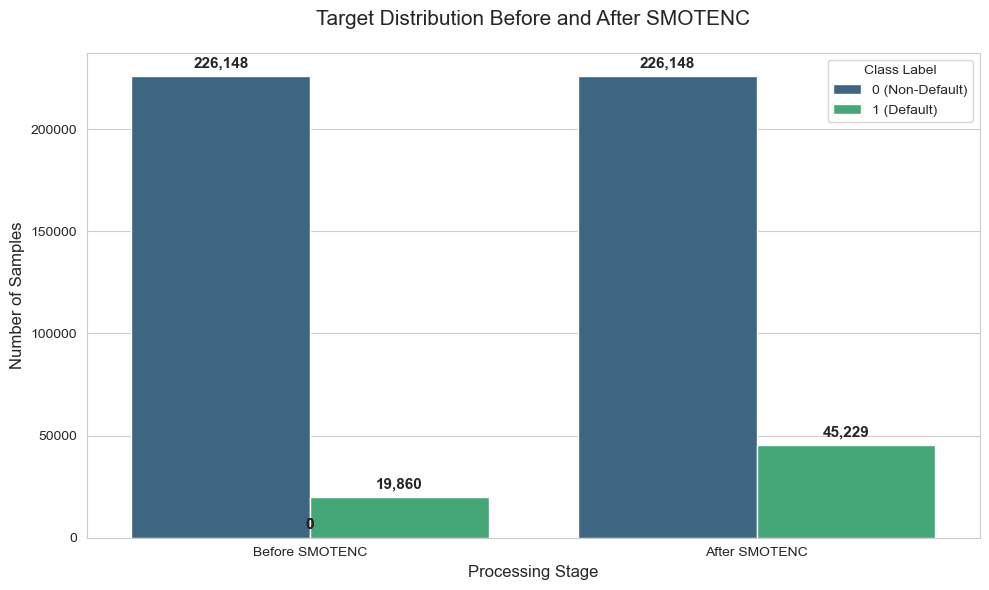

In [43]:
# Visualization: Target Distribution Before vs After SMOTENC

# 1. Prepare data for plotting

pre_counts = y_tr_aligned.value_counts().sort_index()
post_counts = y_tr_resampled.value_counts().sort_index()

# Create a consolidated DataFrame for Seaborn
comparison_df = pd.DataFrame({
    'Target Class': ['0 (Non-Default)', '1 (Default)', '0 (Non-Default)', '1 (Default)'],
    'Sample Count': [pre_counts[0], pre_counts[1], post_counts[0], post_counts[1]],
    'Stage': ['Before SMOTENC', 'Before SMOTENC', 'After SMOTENC', 'After SMOTENC']
})

# 2. Plotting Configuration
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# Use a professional color palette (Viridis)
ax = sns.barplot(data=comparison_df, x='Stage', y='Sample Count', hue='Target Class', palette='viridis')

# 3. Add exact counts on top of each bar for clarity
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

# 4. Labels and Title
plt.title('Target Distribution Before and After SMOTENC', fontsize=15, pad=20)
plt.xlabel('Processing Stage', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.legend(title='Class Label', loc='upper right')
plt.tight_layout()
plt.show()


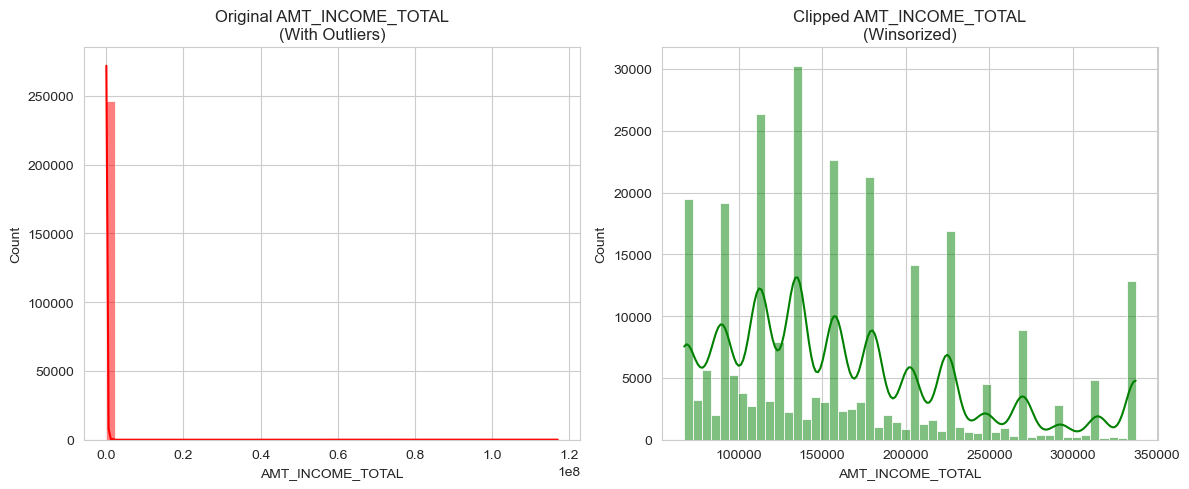

In [66]:
# Pick one high-variance feature to showcase 
feature_to_check = 'AMT_INCOME_TOTAL' 

plt.figure(figsize=(12, 5))

# Original vs Clipped Distribution
plt.subplot(1, 2, 1)
sns.histplot(X_tr_step3[feature_to_check], bins=50, kde=True, color='red')
plt.title(f"Original {feature_to_check}\n(With Outliers)")

plt.subplot(1, 2, 2)
sns.histplot(X_tr_resampled[feature_to_check], bins=50, kde=True, color='green')
plt.title(f"Clipped {feature_to_check}\n(Winsorized)")

plt.tight_layout()
plt.show()